Logistic Regression 

In [1]:
# Cell 1: Import thư viện và khai báo cấu hình chính.
from pathlib import Path
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
from skimage.color import rgb2gray, rgb2hsv
from skimage.feature import hog
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib

DATASET_DIR = Path(r"C:\Users\dungt\Downloads\BCKLTN\dataset_classification")

CLASS_NAMES = ["bad", "good", "shell"]
IMG_SIZE = (128, 128)          # Giảm kích thước để các model ML chạy nhanh hơn
DISPLAY_SIZE = (224, 224)      # Kích thước ảnh khi hiển thị test
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
RANDOM_STATE = 42
N_TEST_IMAGES = 12

FEATURE_TYPE = "color_hog"
COLOR_HIST_BINS = 16
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (16, 16)
HOG_CELLS_PER_BLOCK = (2, 2)

USE_CACHE = True
CACHE_DIR = Path("feature_cache")
CACHE_DIR.mkdir(exist_ok=True)

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


In [2]:
# Cell 2: Đọc ảnh, trích đặc trưng, tải dữ liệu và định nghĩa hàm đánh giá.
def read_image(path, size=IMG_SIZE):
    img = Image.open(path).convert("RGB")
    img = img.resize(size)
    return np.array(img)

def extract_features(img_rgb):
    features = []

    if FEATURE_TYPE in ["histogram", "color_hog"]:
        hsv = rgb2hsv(img_rgb / 255.0)
        for ch in range(3):
            hist, _ = np.histogram(hsv[:, :, ch], bins=COLOR_HIST_BINS, range=(0, 1), density=True)
            features.extend(hist)

    if FEATURE_TYPE in ["hog", "color_hog"]:
        gray = rgb2gray(img_rgb / 255.0)
        hog_features = hog(
            gray,
            orientations=HOG_ORIENTATIONS,
            pixels_per_cell=HOG_PIXELS_PER_CELL,
            cells_per_block=HOG_CELLS_PER_BLOCK,
            block_norm="L2-Hys",
            feature_vector=True
        )
        features.extend(hog_features)

    return np.array(features, dtype=np.float32)

def build_split(split_name):
    X, y, paths = [], [], []
    split_dir = DATASET_DIR / split_name

    if not split_dir.exists():
        raise FileNotFoundError(f"Không tìm thấy thư mục: {split_dir}")

    for class_id, class_name in enumerate(CLASS_NAMES):
        class_dir = split_dir / class_name
        if not class_dir.exists():
            raise FileNotFoundError(f"Không tìm thấy thư mục lớp: {class_dir}")

        for path in sorted(class_dir.rglob("*")):
            if path.suffix.lower() not in IMAGE_EXTENSIONS:
                continue
            try:
                img = read_image(path)
                X.append(extract_features(img))
                y.append(class_id)
                paths.append(str(path))
            except (UnidentifiedImageError, OSError):
                pass

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64), paths

def load_split(split_name):
    cache_file = CACHE_DIR / f"{split_name}_{FEATURE_TYPE}_{IMG_SIZE[0]}x{IMG_SIZE[1]}.npz"

    if USE_CACHE and cache_file.exists():
        data = np.load(cache_file, allow_pickle=True)
        return data["X"], data["y"], list(data["paths"])

    X, y, paths = build_split(split_name)

    if USE_CACHE:
        np.savez_compressed(cache_file, X=X, y=y, paths=np.array(paths, dtype=object))

    return X, y, paths

def evaluate_model(model, X, y, split_name, output_dir=None):
    y_pred = model.predict(X)

    precision = precision_score(y, y_pred, average="macro", zero_division=0)
    recall = recall_score(y, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y, y_pred, average="macro", zero_division=0)

    print(f"\n{split_name.upper()} METRICS")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro):    {recall:.4f}")
    print(f"F1-score (macro):  {f1:.4f}")

    print("\nClassification report:")
    print(classification_report(y, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))

    cm = confusion_matrix(y, y_pred, labels=list(range(len(CLASS_NAMES))))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    plt.title(f"Confusion Matrix - {split_name}")
    plt.tight_layout()

    if output_dir is not None:
        output_dir.mkdir(exist_ok=True)
        plt.savefig(output_dir / f"confusion_matrix_{split_name}.png", dpi=300, bbox_inches="tight")

    plt.show()

    report_df = pd.DataFrame(classification_report(
        y, y_pred, target_names=CLASS_NAMES, output_dict=True, zero_division=0
    )).transpose()

    summary_df = pd.DataFrame([{
        "split": split_name,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }])

    return y_pred, report_df, summary_df, cm

def show_test_images(test_paths, y_true, y_pred, n_images=N_TEST_IMAGES, output_dir=None):
    if len(test_paths) == 0:
        print("Không có ảnh test để hiển thị.")
        return

    n_images = min(n_images, len(test_paths))
    idxs = random.sample(range(len(test_paths)), n_images)

    cols = 4
    rows = int(np.ceil(n_images / cols))
    plt.figure(figsize=(cols * 4, rows * 4))

    for plot_idx, idx in enumerate(idxs, 1):
        path = Path(test_paths[idx])
        img = read_image(path, size=DISPLAY_SIZE)

        plt.subplot(rows, cols, plot_idx)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}",
            fontsize=10
        )

    plt.tight_layout()

    if output_dir is not None:
        output_dir.mkdir(exist_ok=True)
        plt.savefig(output_dir / "test_predictions.png", dpi=300, bbox_inches="tight")

    plt.show()


In [3]:
# Cell 3: Tải dữ liệu train/val/test và thống kê số lượng ảnh từng lớp.
print("Dataset:", DATASET_DIR)

start = time.time()
X_train, y_train, train_paths = load_split("train")
X_val, y_val, val_paths = load_split("val")
X_test, y_test, test_paths = load_split("test")
print(f"Thời gian tải/trích đặc trưng: {time.time() - start:.2f} giây")

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

for split_name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    counts = pd.Series(y).value_counts().sort_index()
    print(f"\n{split_name.upper()}:")
    for class_id, class_name in enumerate(CLASS_NAMES):
        print(f"{class_name}: {counts.get(class_id, 0)}")


Dataset: C:\Users\dungt\Downloads\BCKLTN\dataset_classification
Thời gian tải/trích đặc trưng: 0.48 giây
Train: (6110, 1812) (6110,)
Val:   (2990, 1812) (2990,)
Test:  (1886, 1812) (1886,)

TRAIN:
bad: 1792
good: 2712
shell: 1606

VAL:
bad: 816
good: 1551
shell: 623

TEST:
bad: 579
good: 632
shell: 675


In [4]:
# Cell 4: Khởi tạo và huấn luyện mô hình Logistic Regression.
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

start = time.time()
model.fit(X_train, y_train)
print(f"Đã huấn luyện xong Logistic Regression trong {time.time() - start:.2f} giây.")


Đã huấn luyện xong Logistic Regression trong 4.50 giây.



TEST METRICS
Precision (macro): 0.8836
Recall (macro):    0.8607
F1-score (macro):  0.8511

Classification report:
              precision    recall  f1-score   support

         bad     0.6867    0.9879    0.8102       579
        good     0.9869    0.9573    0.9719       632
       shell     0.9773    0.6370    0.7713       675

    accuracy                         0.8521      1886
   macro avg     0.8836    0.8607    0.8511      1886
weighted avg     0.8913    0.8521    0.8505      1886



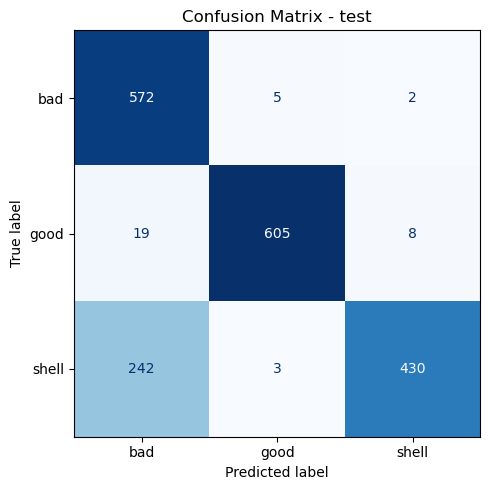

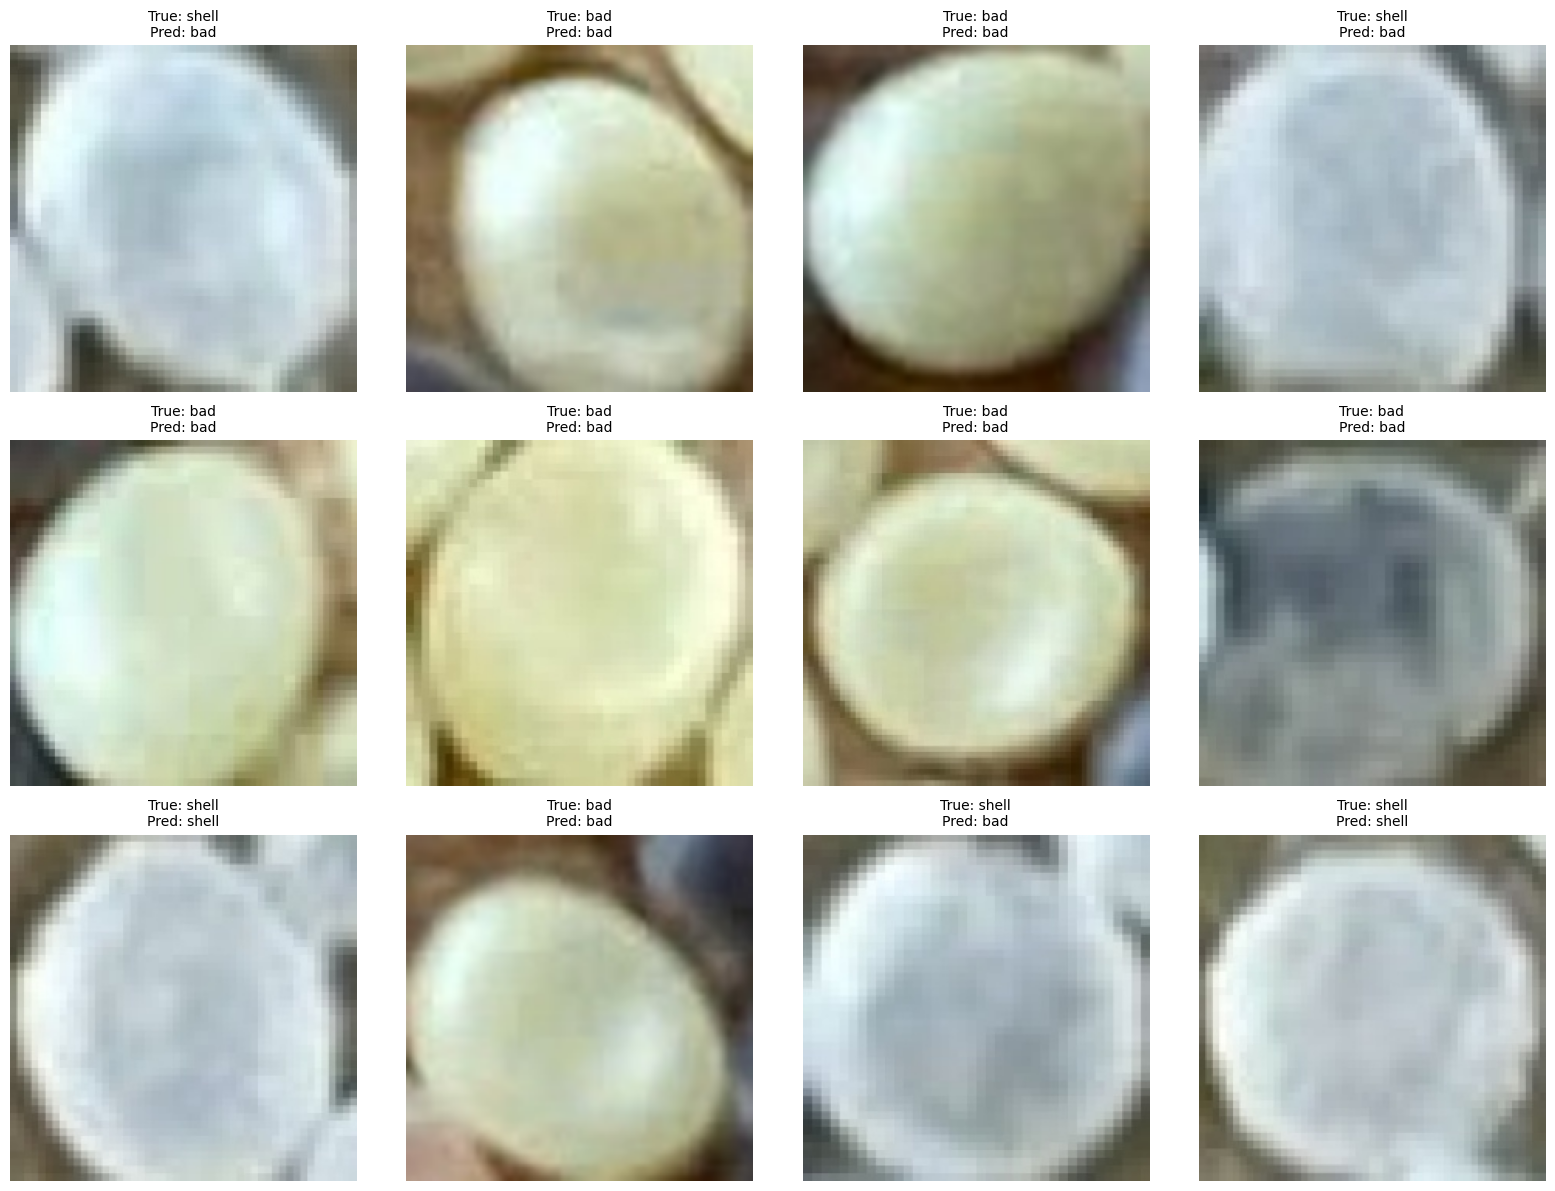

Đã lưu kết quả vào: outputs_logistic_regression


In [5]:
# Cell 5: Đánh giá trên tập test, hiển thị ảnh test và lưu kết quả.
output_dir = Path("outputs_logistic_regression")
output_dir.mkdir(exist_ok=True)

y_pred_test, report_df, summary_df, cm = evaluate_model(model, X_test, y_test, "test", output_dir)
show_test_images(test_paths, y_test, y_pred_test, output_dir=output_dir)

report_df.to_csv(output_dir / "logistic_regression_classification_report.csv", encoding="utf-8-sig")
summary_df.to_csv(output_dir / "logistic_regression_metrics_summary.csv", index=False, encoding="utf-8-sig")
joblib.dump(model, output_dir / "logistic_regression_model.pkl")

print("Đã lưu kết quả vào:", output_dir)
